### 1. Dataset Overview
Loading the dataset and displaying the first few rows, shape, column names, and data types.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the dataset
df = pd.read_csv('survey.csv')

# Display the first 3 rows
display(df.head(3))

# Show dataset shape and data types
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
print("Data Types:")
print(df.dtypes)

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN


Dataset Shape: 1259 rows, 27 columns.

Data Types:
Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments     

### 2. Data Quality Checks & Cleaning
Checking for missing values, duplicates, and cleaning the data so it is ready for text classification.

In [14]:
# Check for missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

# DATA CLEANING
# Drop rows with blank comments
df_clean = df.dropna(subset=['comments']).copy()

# Drop comments with 2 or fewer words (e.g., "N/A", "None")
df_clean['word_count'] = df_clean['comments'].apply(lambda x: len(str(x).split()))
df_clean = df_clean[df_clean['word_count'] > 2].copy()

# Clean invalid ages
df_clean = df_clean[(df_clean['Age'] > 15) & (df_clean['Age'] < 80)].copy()

# Standardize Gender
df_clean['Gender'] = df_clean['Gender'].str.lower().str.strip()
def standardize_gender(text):
    if pd.isna(text): return 'unknown'
    if text in ['m', 'male', 'make', 'man', 'cis male', 'mail']: return 'male'
    elif text in ['f', 'female', 'woman', 'cis female', 'femail']: return 'female'
    else: return 'others'
df_clean['Gender_Clean'] = df_clean['Gender'].apply(standardize_gender)

print(f"\nFinal cleaned dataset size for EDA visualizations: {len(df_clean)} rows.")

Missing values per column:
comments          1095
state              515
work_interfere     264
self_employed       18
Gender               0
Timestamp            0
Age                  0
family_history       0
treatment            0
no_employees         0
dtype: int64

Total duplicate rows: 0

Final cleaned dataset size for EDA visualizations: 159 rows.


### 3. Exploratory Data Analysis (Visualizations)
Visualizing the target variable, demographics, and text characteristics.

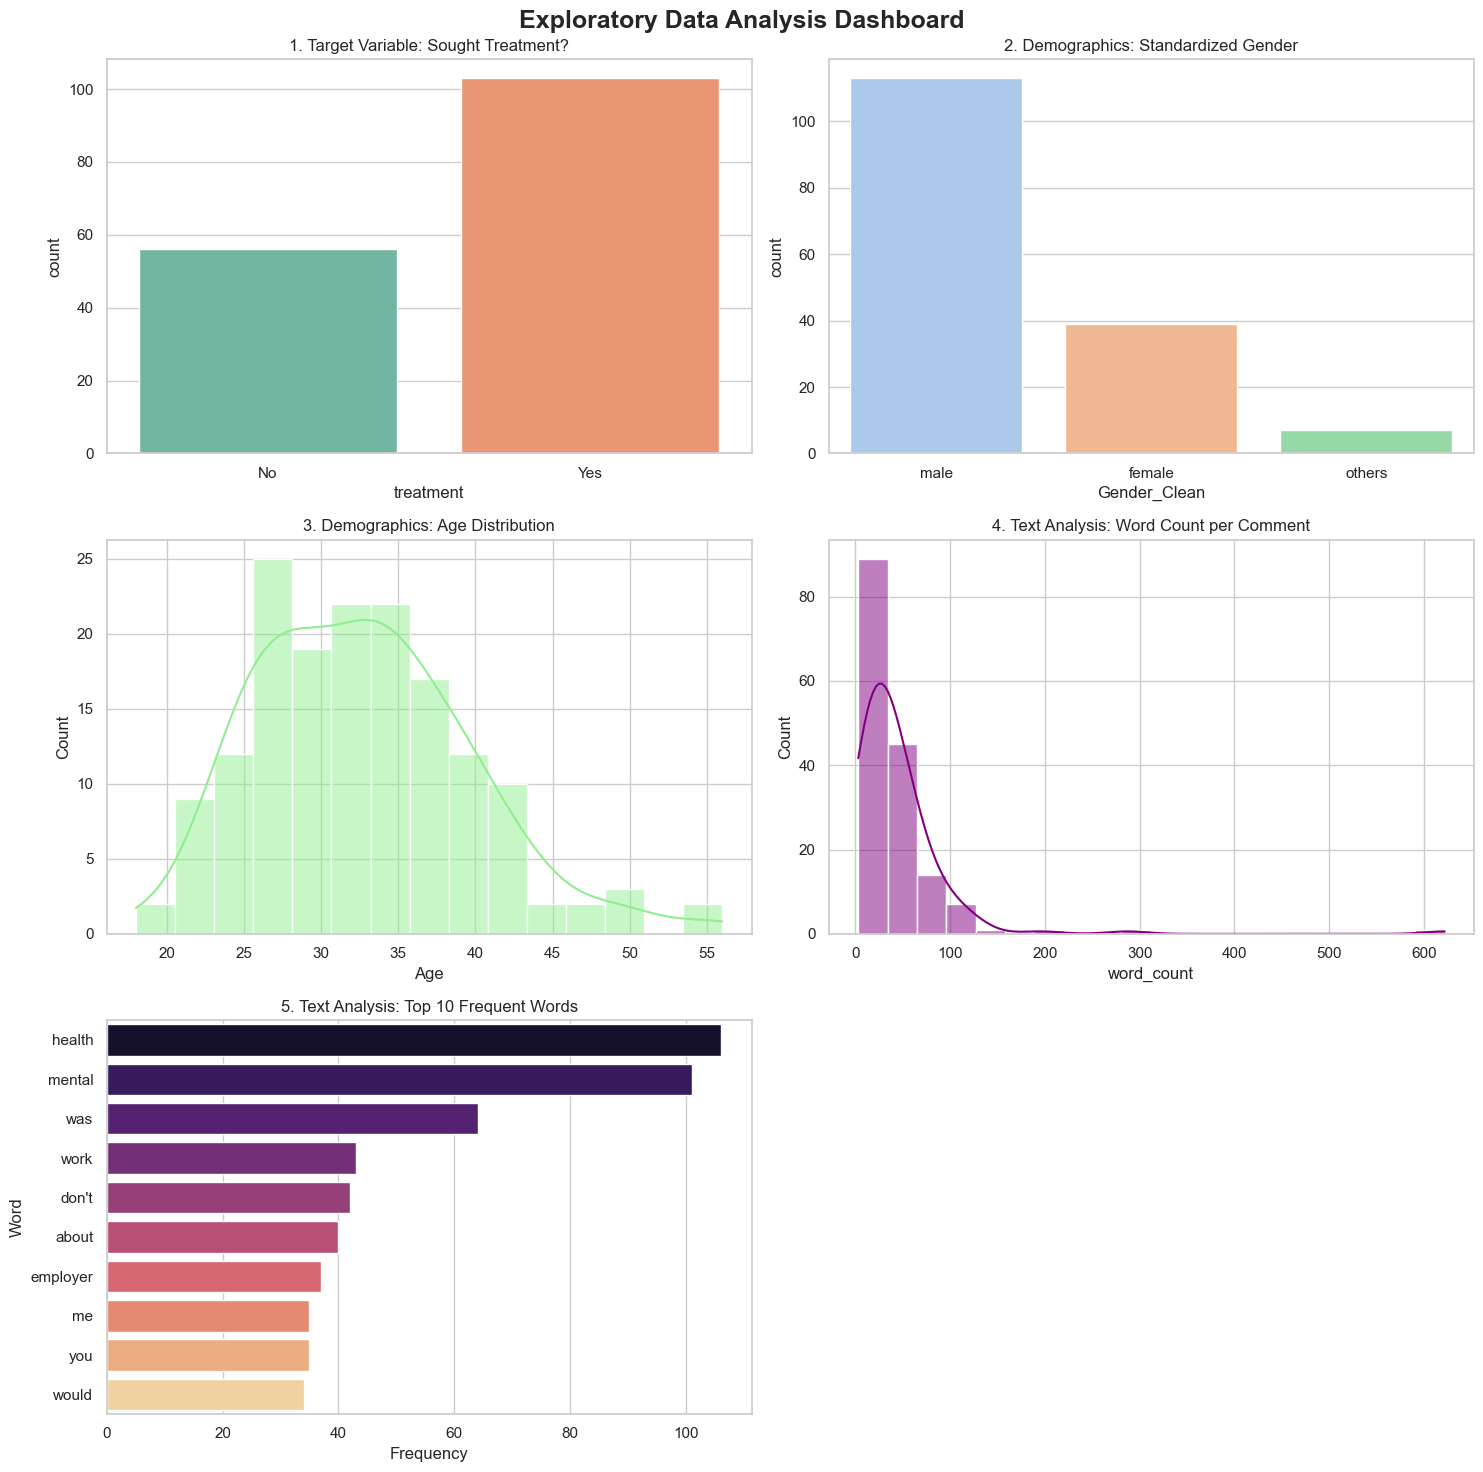

In [15]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Exploratory Data Analysis Dashboard', fontsize=18, fontweight='bold')

# Visualization 1: Target Variable (Treatment)
sns.countplot(data=df_clean, x='treatment', hue='treatment', palette='Set2', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('1. Target Variable: Sought Treatment?')

# Visualization 2: Gender Distribution
sns.countplot(data=df_clean, x='Gender_Clean', hue='Gender_Clean', palette='pastel', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('2. Demographics: Standardized Gender')

# Visualization 3: Age Distribution
sns.histplot(data=df_clean, x='Age', bins=15, color='lightgreen', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('3. Demographics: Age Distribution')

# Visualization 4: Text Length (Word Count)
sns.histplot(data=df_clean, x='word_count', bins=20, color='purple', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('4. Text Analysis: Word Count per Comment')

# Visualization 5: Top 10 Most Frequent Meaningful Words
all_words = ' '.join(df_clean['comments'].astype(str).tolist()).lower().split()
stop_words = {'the', 'and', 'i', 'to', 'a', 'of', 'in', 'it', 'for', 'is', 'that', 'my', 'but', 'with', 'on', 'have', 'are', 'not', 'be', 'this', 'as', 'or', 'they', 'at', 'so'}
meaningful_words = [word for word in all_words if word not in stop_words]
common_words = pd.DataFrame(Counter(meaningful_words).most_common(10), columns=['Word', 'Frequency'])

sns.barplot(data=common_words, x='Frequency', y='Word', hue='Word', palette='magma', legend=False, ax=axes[2, 0])
axes[2, 0].set_title('5. Text Analysis: Top 10 Frequent Words')

# Remove the empty 6th subplot
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

### 4. Interpretation and Observations

The exploratory data analysis of the mental health survey highlights four main observations. First, the text column had a large amount of missing or very short answers. This required heavy data cleaning to prepare the text for classification. Second, the target variable is slightly unbalanced because a higher number of respondents reported seeking treatment compared to those who did not. Third, the demographic data shows that most users in the final dataset are men between their late twenties and mid-thirties. Because of this, the comments mainly show the viewpoint of this specific group within the tech industry. Lastly, most written responses are short and contain fewer than fifty words. However, there are a few very long comments that will need careful handling during the model training phase.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

# Import your 5 specific models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# X is the text features, y is the target variable
X = df_clean['comments']
y = df_clean['treatment']

# Split the data: 80% for training the models, 20% for testing them
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the text words into numerical values using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test) 

print("Data successfully vectorized and split into training/testing sets.")

Data successfully vectorized and split into training/testing sets.


In [19]:
# Initialize the 5 models in a dictionary so we can loop through them easily
models = {
    "Model A: Decision Tree": DecisionTreeClassifier(random_state=42),
    "Model B: Naive Bayes": MultinomialNB(),
    "Model C: Linear Regression": LinearRegression(),
    "Model D: KNN": KNeighborsClassifier(n_neighbors=5),
    "Model E: Logistic Regression": LogisticRegression(random_state=42)
}

print("5 Models loaded and ready for training.")

5 Models loaded and ready for training.


In [ ]:
results = []

for model_name, model in models.items():
    
    # --- Special Handling for Linear Regression ---
    if model_name == "Model C: Linear Regression":
        # Convert Yes/No to 1/0 for training
        y_train_numeric = np.where(y_train == 'Yes', 1, 0)
        model.fit(X_train_vec, y_train_numeric)
        
        # Predict numbers, then apply a 0.5 threshold to turn them back to Yes/No
        predictions_numeric = model.predict(X_test_vec)
        y_pred = np.where(predictions_numeric >= 0.5, 'Yes', 'No')
        
    # --- Normal Handling for the other 4 models ---
    else:
        model.fit(X_train_vec, y_train)
        y_pred = model.predict(X_test_vec)
    
    
    # Calculate Core Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='Yes', zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label='Yes', zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label='Yes', zero_division=0)
    
    # Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=['No', 'Yes'])
    tn, fp, fn, tp = cm.ravel()
    
    # Save the results
    results.append({
        "Classifier Model": model_name,
        "Accuracy": round(acc, 2),
        "Precision": round(prec, 2),
        "Recall": round(rec, 2),
        "F1-Score": round(f1, 2),
        "TP (Correct 'Yes')": tp,
        "FP (Wrong 'Yes')": fp,
        "TN (Correct 'No')": tn,
        "FN (Missed 'Yes')": fn
    })

print("All models have been trained and evaluated.")

Training models and calculating metrics... please wait.

Step 3 Complete: All models have been trained and evaluated.


In [ ]:
# Convert the main results list into a Pandas DataFrame
results_df = pd.DataFrame(results)

# --- 1. PREPARE THE SEPARATE TABLES ---

# Table 1: Accuracy Score Only
accuracy_cols = ['Classifier Model', 'Accuracy']
accuracy_df = results_df[accuracy_cols].sort_values(by='Accuracy', ascending=False) # Sorted highest to lowest!

# Table 2: Confusion Matrix (Headcounts)
cm_columns = ['Classifier Model', 'TP (Correct \'Yes\')', 'FP (Wrong \'Yes\')', 'TN (Correct \'No\')', 'FN (Missed \'Yes\')']
cm_df = results_df[cm_columns]

# Table 3: Core Metrics (Detailed Percentages)
core_cols = ['Classifier Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
core_df = results_df[core_cols]


# --- 2. DISPLAY THE TABLES IN ORDER ---

# First: ACCURACY SCORE
print("=== 1. ACCURACY SCORE ===")
display(accuracy_df)

print("\n" + "="*70 + "\n")

# Second: CONFUSION MATRIX
print("=== 2. CONFUSION MATRIX ===")
display(cm_df)

print("\n" + "="*70 + "\n")

# Third: CORE METRICS
print("=== 3. CORE METRICS ===")
display(core_df)

print("\n" + "="*70 + "\n")



=== 1. ACCURACY SCORE ===


,Classifier Model,Accuracy
4,Model E: Logistic Regression,0.62
1,Model B: Naive Bayes,0.59
2,Model C: Linear Regression,0.56
0,Model A: Decision Tree,0.53
3,Model D: KNN,0.44




=== 2. CONFUSION MATRIX ===


,Classifier Model,TP (Correct 'Yes'),FP (Wrong 'Yes'),TN (Correct 'No'),FN (Missed 'Yes')
0,Model A: Decision Tree,11,6,6,9
1,Model B: Naive Bayes,19,12,0,1
2,Model C: Linear Regression,10,4,8,10
3,Model D: KNN,9,7,5,11
4,Model E: Logistic Regression,20,12,0,0




=== 3. CORE METRICS ===


,Classifier Model,Accuracy,Precision,Recall,F1-Score
0,Model A: Decision Tree,0.53,0.65,0.55,0.59
1,Model B: Naive Bayes,0.59,0.61,0.95,0.75
2,Model C: Linear Regression,0.56,0.71,0.50,0.59
3,Model D: KNN,0.44,0.56,0.45,0.50
4,Model E: Logistic Regression,0.62,0.62,1.00,0.77
